# 1. Importar librerias


In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import random

# Esta es para mas tarde
import seaborn as sns
sns.set_style("white")

#2. Inicializar algunas variables



In [87]:
hostnames = []
dataset = []
df = None

#3. Funcion para generar hostnames


In [88]:
def set_hostnames(number_of_hosts: int) -> None:
 hostname_so = ["L"]*40 + ["S"]*30 + ["A"]*20 + ["H"]*10
 hostname_enviroment = ["D"]*10 + ["I"]*10 + ["T"]*25 + ["S"]*25
 hostname_country = ["NOR"]*6 + ["FRA"]*9+["ITA"]*16 + ["ESP"]*16+["DEU"]*23 + ["IRL"]*30
 parte_alpha = []

 for _ in range(number_of_hosts):
  hostname = random.choice(hostname_so) + random.choice(hostname_enviroment) + random.choice(hostname_country)
  parte_alpha.append(hostname)
  hostname +=  str(parte_alpha.count(hostname)).zfill(3)
  hostnames.append(hostname)

#4. Funcion para obtener nombre del SO


In [89]:
def get_os(hostname: str) -> str:
  if hostname[0] == "L":
    return "Linux"
  elif hostname[0] == "S":
    return "Solaris"
  elif hostname[0] == "A":
    return "AIX"
  elif hostname[0] == "H":
    return "HP-UX"
  else:
    return "Unknow"

#5. Funcion para obtener nombre del entorno

In [90]:
def get_enviroment(hostname: str) -> str:
  if hostname[1] == "D":
    return "Development"
  elif hostname[1] == "I":
    return "Integration"
  elif hostname[1] == "T":
    return "Testing"
  elif hostname[1] == "S":
    return "Staging"
  elif hostname[1] == "P":
    return "Production"
  else:
    return "Unknow"

#6. Funcion para obtener nombre del pais

In [91]:
def get_country(hostname: str) -> str:
  if hostname[2:5] == "NOR":
    return "Norway"
  elif hostname[2:5] == "FRA":
    return "France"
  elif hostname[2:5] == "ITA":
    return "Italy"
  elif hostname[2:5] == "ESP":
    return "Spain"
  elif hostname[2:5] == "DEU":
    return "Germany"
  elif hostname[2:5] == "IRL":
    return "Ireland"
  else:
    return "Unknow"

#7. Funcion para generar DataFrame

In [92]:
def set_dataframe(count: int) -> None:
  global df

  set_hostnames(count)

  for hostname in hostnames:
    dataset.append({
        "hostname": hostname,
        "os": get_os(hostname),
        "enviroment": get_enviroment(hostname),
        "country": get_country(hostname),
        "nodo": int(hostname[-3:])
    })
    df = pd.DataFrame(dataset)

#8. Crear el DataFrame


In [93]:
set_dataframe(1500)
df

,hostname,os,enviroment,country,nodo
0,SSIRL001,Solaris,Staging,Ireland,1
1,ATDEU001,AIX,Testing,Germany,1
2,AIFRA001,AIX,Integration,France,1
3,SIIRL001,Solaris,Integration,Ireland,1
4,SSDEU001,Solaris,Staging,Germany,1
...,...,...,...,...,...
1495,LSIRL067,Linux,Staging,Ireland,67
1496,LSIRL068,Linux,Staging,Ireland,68
1497,LIITA014,Linux,Integration,Italy,14
1498,AINOR002,AIX,Integration,Norway,2


#9. Guardar el DataFrame en un fichero CSV

In [94]:
df.to_csv("hosts.csv",header = True, index = False)

df_hosts = pd.read_csv("hosts.csv")
df_hosts

,hostname,os,enviroment,country,nodo
0,SSIRL001,Solaris,Staging,Ireland,1
1,ATDEU001,AIX,Testing,Germany,1
2,AIFRA001,AIX,Integration,France,1
3,SIIRL001,Solaris,Integration,Ireland,1
4,SSDEU001,Solaris,Staging,Germany,1
...,...,...,...,...,...
1495,LSIRL067,Linux,Staging,Ireland,67
1496,LSIRL068,Linux,Staging,Ireland,68
1497,LIITA014,Linux,Integration,Italy,14
1498,AINOR002,AIX,Integration,Norway,2


#10. Generar un unico grafico, agrupando para cada pais los entornos

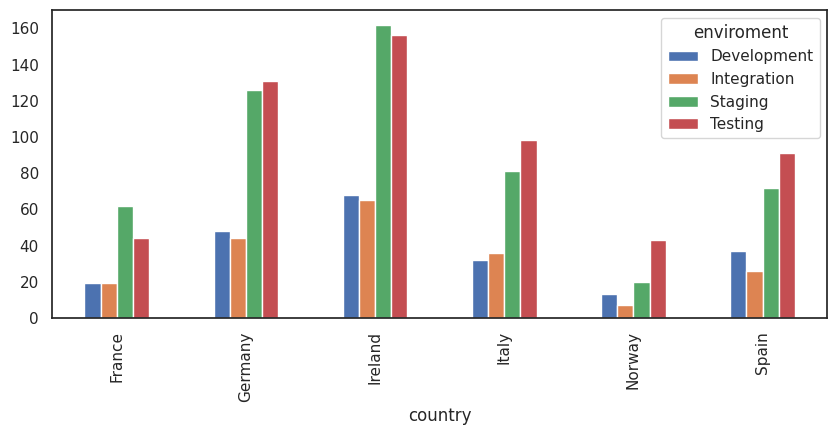

In [95]:
g = df.groupby(["country", "enviroment"]).size()
g.unstack().plot(kind="bar",figsize=(10,4));


#11. Crear una figura con 4 gráficos en una malla de 2 filas y 2 columnas

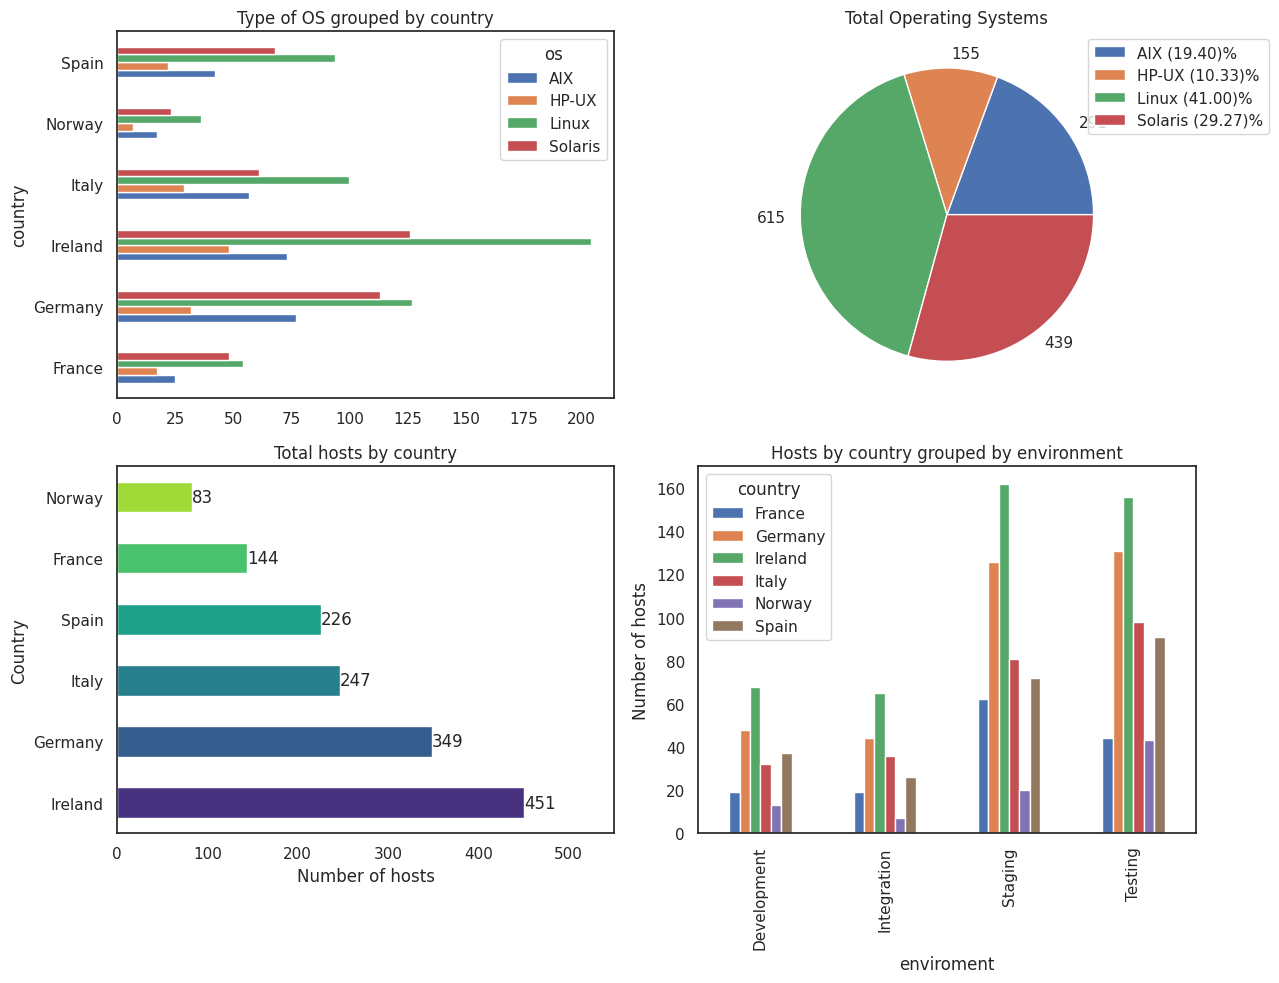

In [96]:
fig, axs = plt.subplots(2, 2) # creo primero la malla

# Grafica esquina superior izquierda
axs[0, 0].set_title('Type of OS grouped by country');
df.groupby(["country", "os"]).size().unstack().plot(kind="barh",figsize=(13,11), ax=axs[0, 0]);

# Grafica esquina superior derecha
axs[0, 1].set_title('Total Operating Systems');
axs[0, 1].pie(df.groupby(["os"]).size(), labels=df.groupby(["os"]).size());

porcentajes = df.groupby(["os"]).size()/df.groupby(["os"]).size().sum()*100;
leyenda = [f'{so} ({per:1.2f})%' for so, per in zip(df.groupby(["os"]).size().index, porcentajes)];
axs[0, 1].legend(labels = leyenda, loc ="upper right",bbox_to_anchor=(1.4, 1));

# Grafica esquina inferior izquierda
axs[1, 0].set_title('Total hosts by country')
df["country"].value_counts().plot(kind="barh",color = sns.color_palette("viridis"), ax=axs[1, 0]);

axs[1, 0].set_xlabel("Number of hosts");
axs[1, 0].set_ylabel("Country")

axs[1, 0].bar_label(axs[1, 0].containers[0]);
axs[1, 0].set_xlim(0,df["country"].value_counts().max() + 100)

# Grafica esquina inferior derecha

axs[1, 1].set_title('Hosts by country grouped by environment')
df.groupby(["country", "enviroment"]).size().unstack(0).plot(kind="bar",figsize=(13,10), ax=axs[1,1]);

axs[1, 1].set_ylabel("Number of hosts");


fig.tight_layout();